# Exploratory data analysis

This notebook explicitly loads and explores each repository dataset. It intentionally avoids helper functions so every section can be edited and extended. Install with `python -m pip install pandas openpyxl geopandas matplotlib seaborn jupyter`.

Documentation rules applied: REFEPS `total` is an aggregate count; `99`, `999`, and `9999` are missing sentinels; BAHRA contains settlements; census-radio metadata documents EPSG:4326.

In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
ROOT = Path(".")
CSV_NA = ["", "NA", "N/A", "null", "NULL"]
print(ROOT.resolve())

C:\Users\anapa\OneDrive\Escritorio\facu\radio


## 1. Enfermería 2023

In [2]:
enfermeria = pd.read_csv(ROOT / "enfermeria-2023.csv", encoding="utf-8", na_values=CSV_NA, dtype={"sexo":"string", "grupo_etareo":"string", "id_provincia_residencia":"Int64", "provincia_residencia":"string", "id_pais_nacimiento":"Int64", "pais_nacimiento":"string", "pais_origen":"string", "id_profesion_referencia":"Int64", "profesion_referencia":"string", "id_pais_formacion":"Int64", "pais_formacion":"string", "id_provincia_formacion":"Int64", "provincia_formacion":"string", "id_institucion_formadora":"Int64", "institucion_formadora":"string", "anio_titulo":"Int64", "total":"Int64", "anio_corte":"Int64"});
for column in ["id_pais_nacimiento", "id_pais_formacion", "id_provincia_residencia", "id_provincia_formacion", "anio_titulo", "id_institucion_formadora"]: enfermeria[column] = enfermeria[column].replace([99,999,9999], pd.NA).astype("Int64")
print(enfermeria.shape); display(enfermeria.head()); display(enfermeria.dtypes.to_frame("dtype"))

(88044, 18)


,sexo,grupo_etareo,id_provincia_residencia,provincia_residencia,id_pais_nacimiento,pais_nacimiento,pais_origen,id_profesion_referencia,profesion_referencia,id_pais_formacion,pais_formacion,id_provincia_formacion,provincia_formacion,id_institucion_formadora,institucion_formadora,anio_titulo,total,anio_corte
0,F,35-39,14,Córdoba,200,Argentina,Argentina,15,Enfermero,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,2010,1,2023
1,F,35-39,14,Córdoba,200,Argentina,Argentina,15,Enfermero,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,2015,1,2023
2,F,35-39,22,Chaco,200,Argentina,Argentina,15,Enfermero,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,2023,1,2023
3,F,35-39,30,Entre Ríos,200,Argentina,Argentina,15,Enfermero,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,2009,1,2023
4,F,35-39,30,Entre Ríos,200,Argentina,Argentina,15,Enfermero,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,2010,1,2023


,dtype
sexo,string
grupo_etareo,string
id_provincia_residencia,Int64
provincia_residencia,string
id_pais_nacimiento,Int64
pais_nacimiento,string
pais_origen,string
id_profesion_referencia,Int64
profesion_referencia,string
id_pais_formacion,Int64


In [3]:
enfermeria_missing = enfermeria.isna().sum().to_frame("missing"); enfermeria_missing["missing_pct"] = enfermeria_missing["missing"] / len(enfermeria) * 100; display(enfermeria_missing.sort_values("missing", ascending=False)); print("Duplicate rows:", enfermeria.duplicated().sum()); enfermeria_outliers=[]
for column in enfermeria.select_dtypes(include="number").columns:
 values=enfermeria[column].dropna().astype(float); q1,q3=values.quantile([.25,.75]); iqr=q3-q1; lower,upper=q1-1.5*iqr,q3+1.5*iqr; enfermeria_outliers.append([column,q1,q3,lower,upper,int(((values<lower)|(values>upper)).sum())])
display(pd.DataFrame(enfermeria_outliers, columns=["column","q1","q3","lower","upper","outlier_count"]))

,missing,missing_pct
id_provincia_formacion,15354,17.439008
id_pais_formacion,14882,16.902912
id_institucion_formadora,14882,16.902912
id_pais_nacimiento,777,0.882513
grupo_etareo,0,0.000000
sexo,0,0.000000
pais_nacimiento,0,0.000000
pais_origen,0,0.000000
provincia_residencia,0,0.000000
id_provincia_residencia,0,0.000000


Duplicate rows: 0


,column,q1,q3,lower,upper,outlier_count
0,id_provincia_residencia,6.0,50.00,-60.000,116.000,0
1,id_pais_nacimiento,200.0,200.00,200.000,200.000,12832
2,id_profesion_referencia,15.0,32.00,-10.500,57.500,0
3,id_pais_formacion,200.0,200.00,200.000,200.000,408
4,id_provincia_formacion,2.0,30.00,-40.000,72.000,7925
5,id_institucion_formadora,1128.0,1402.75,715.875,1814.875,10326
6,anio_titulo,2006.0,2018.00,1988.000,2036.000,4414
7,total,1.0,3.00,-2.000,6.000,8467
8,anio_corte,2023.0,2023.00,2023.000,2023.000,0


Professionals represented: 285861


,professionals
sexo,
F,233171
M,52689
S/e,1


,professionals
grupo_etareo,
20-24,2547
25-29,19486
30-34,35393
35-39,39121
40-44,39990
45-49,34171
50-54,29342
55-59,25325
60-64,22371


,professionals
provincia_residencia,
Buenos Aires,116390
Ciudad Autónoma de Buenos Aires,26074
Santa Fe,18121
Córdoba,16904
Mendoza,11656
Entre Ríos,11297
Salta,10054
Tucumán,9972
Chaco,8688


,professionals
pais_origen,
Argentina,268462
Extranjero,16475
Desconocido,924


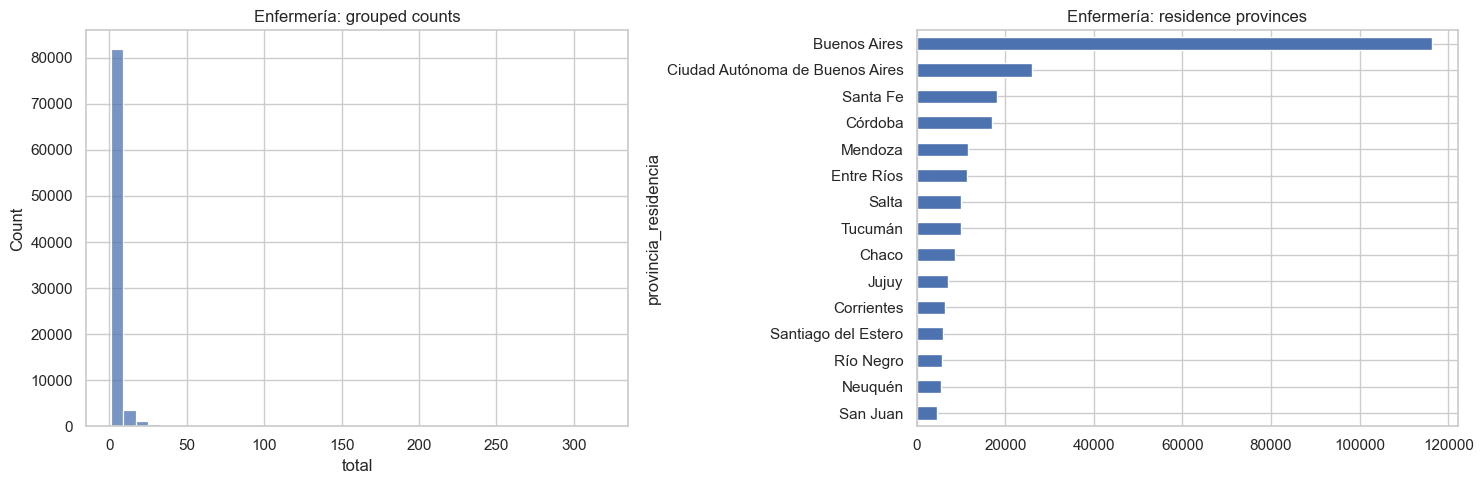

In [4]:
print("Professionals represented:", enfermeria["total"].sum()); display(enfermeria.groupby("sexo",dropna=False)["total"].sum().sort_values(ascending=False).to_frame("professionals")); display(enfermeria.groupby("grupo_etareo",dropna=False)["total"].sum().sort_index().to_frame("professionals")); display(enfermeria.groupby("provincia_residencia",dropna=False)["total"].sum().sort_values(ascending=False).head(15).to_frame("professionals")); display(enfermeria.groupby("pais_origen",dropna=False)["total"].sum().sort_values(ascending=False).to_frame("professionals")); fig,axes=plt.subplots(1,2,figsize=(15,5)); sns.histplot(data=enfermeria,x="total",bins=40,ax=axes[0]); axes[0].set_title("Enfermería: grouped counts"); enfermeria.groupby("provincia_residencia")["total"].sum().sort_values(ascending=False).head(15).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("Enfermería: residence provinces"); plt.tight_layout(); plt.show()

## 2. Medicina 2023

In [5]:
medicos = pd.read_csv(ROOT / "medicos-2023.csv", encoding="utf-8", na_values=CSV_NA, dtype={"sexo":"string", "grupo_etareo":"string", "id_provincia_residencia":"Int64", "provincia_residencia":"string", "id_pais_nacimiento":"Int64", "pais_nacimiento":"string", "pais_origen":"string", "id_profesion_referencia":"Int64", "profesion_referencia":"string", "id_pais_formacion":"Int64", "pais_formacion":"string", "id_provincia_formacion":"Int64", "provincia_formacion":"string", "id_institucion_formadora":"Int64", "institucion_formadora":"string", "anio_titulo":"Int64", "total":"Int64", "anio_corte":"Int64"});
for column in ["id_pais_nacimiento", "id_pais_formacion", "id_provincia_residencia", "id_provincia_formacion", "anio_titulo", "id_institucion_formadora"]: medicos[column] = medicos[column].replace([99,999,9999], pd.NA).astype("Int64")
print(medicos.shape); display(medicos.head()); display(medicos.dtypes.to_frame("dtype"))

(47219, 18)


,sexo,grupo_etareo,id_provincia_residencia,provincia_residencia,id_pais_nacimiento,pais_nacimiento,pais_origen,id_profesion_referencia,profesion_referencia,id_pais_formacion,pais_formacion,id_provincia_formacion,provincia_formacion,id_institucion_formadora,institucion_formadora,anio_titulo,total,anio_corte
0,M,85+,30,Entre Ríos,200,Argentina,Argentina,35,Médico,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,1941,1,2023
1,M,85+,30,Entre Ríos,200,Argentina,Argentina,35,Médico,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,1942,1,2023
2,M,85+,30,Entre Ríos,200,Argentina,Argentina,35,Médico,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,1946,1,2023
3,M,85+,30,Entre Ríos,200,Argentina,Argentina,35,Médico,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,1947,1,2023
4,M,85+,30,Entre Ríos,200,Argentina,Argentina,35,Médico,200,Argentina,2,Ciudad Autónoma de Buenos Aires,1172,UNIVERSIDAD DE BUENOS AIRES,1958,1,2023


,dtype
sexo,string
grupo_etareo,string
id_provincia_residencia,Int64
provincia_residencia,string
id_pais_nacimiento,Int64
pais_nacimiento,string
pais_origen,string
id_profesion_referencia,Int64
profesion_referencia,string
id_pais_formacion,Int64


In [6]:
medicos_missing=medicos.isna().sum().to_frame("missing"); medicos_missing["missing_pct"]=medicos_missing["missing"]/len(medicos)*100; display(medicos_missing.sort_values("missing",ascending=False)); print("Duplicate rows:",medicos.duplicated().sum()); medicos_outliers=[]
for column in medicos.select_dtypes(include="number").columns:
 values=medicos[column].dropna().astype(float); q1,q3=values.quantile([.25,.75]); iqr=q3-q1; lower,upper=q1-1.5*iqr,q3+1.5*iqr; medicos_outliers.append([column,q1,q3,lower,upper,int(((values<lower)|(values>upper)).sum())])
display(pd.DataFrame(medicos_outliers,columns=["column","q1","q3","lower","upper","outlier_count"]))

,missing,missing_pct
id_provincia_formacion,5156,10.919333
id_pais_formacion,4936,10.453419
id_institucion_formadora,4936,10.453419
id_pais_nacimiento,514,1.088545
grupo_etareo,0,0.000000
sexo,0,0.000000
pais_nacimiento,0,0.000000
pais_origen,0,0.000000
provincia_residencia,0,0.000000
id_provincia_residencia,0,0.000000


Duplicate rows: 0


,column,q1,q3,lower,upper,outlier_count
0,id_provincia_residencia,6.0,58.0,-72.0,136.0,0
1,id_pais_nacimiento,200.0,202.0,197.0,205.0,6578
2,id_profesion_referencia,35.0,35.0,35.0,35.0,0
3,id_pais_formacion,200.0,200.0,200.0,200.0,7456
4,id_provincia_formacion,2.0,82.0,-118.0,202.0,0
5,id_institucion_formadora,1172.0,1326.0,941.0,1557.0,4769
6,anio_titulo,1989.0,2014.0,1951.5,2051.5,228
7,total,1.0,3.0,-2.0,6.0,5949
8,anio_corte,2023.0,2023.0,2023.0,2023.0,0


Professionals represented: 231737


,professionals
sexo,
F,120534
M,111203


,professionals
grupo_etareo,
20-24,503
25-29,14830
30-34,25502
35-39,29611
40-44,28757
45-49,25648
50-54,21711
55-59,19098
60-64,13871


,professionals
provincia_residencia,
Buenos Aires,64510
Ciudad Autónoma de Buenos Aires,62140
Córdoba,19977
Santa Fe,18785
Mendoza,9441
Tucumán,7223
Entre Ríos,5928
Corrientes,4895
Salta,4469


,professionals
pais_origen,
Argentina,205459
Extranjero,25631
Desconocido,647


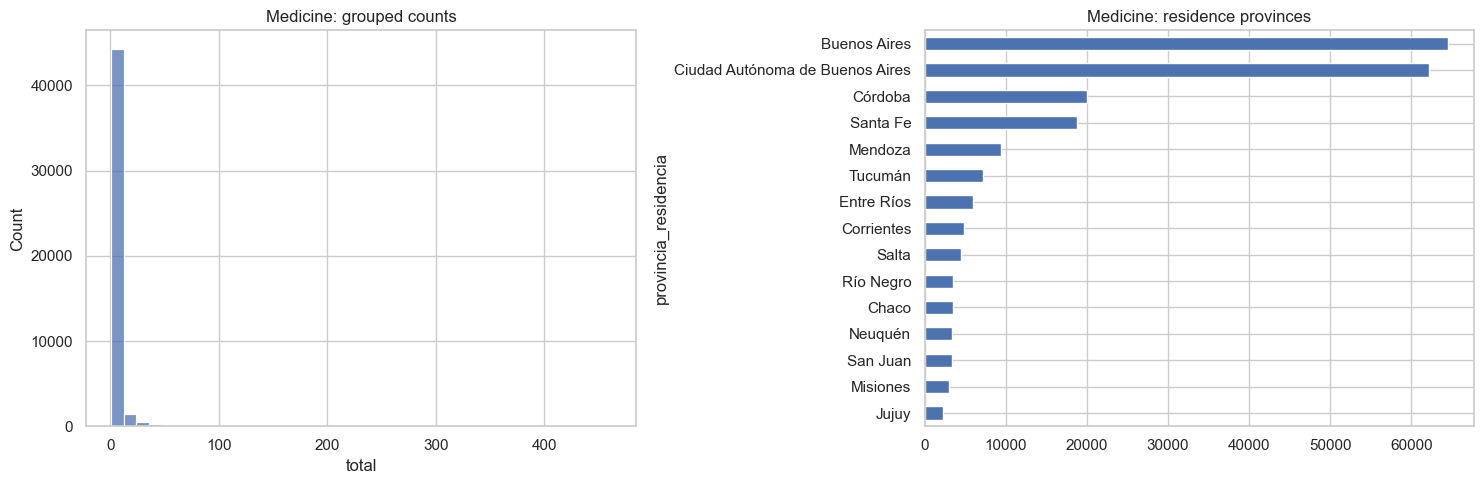

In [7]:
print("Professionals represented:",medicos["total"].sum()); display(medicos.groupby("sexo",dropna=False)["total"].sum().sort_values(ascending=False).to_frame("professionals")); display(medicos.groupby("grupo_etareo",dropna=False)["total"].sum().sort_index().to_frame("professionals")); display(medicos.groupby("provincia_residencia",dropna=False)["total"].sum().sort_values(ascending=False).head(15).to_frame("professionals")); display(medicos.groupby("pais_origen",dropna=False)["total"].sum().sort_values(ascending=False).to_frame("professionals")); fig,axes=plt.subplots(1,2,figsize=(15,5)); sns.histplot(data=medicos,x="total",bins=40,ax=axes[0]); axes[0].set_title("Medicine: grouped counts"); medicos.groupby("provincia_residencia")["total"].sum().sort_values(ascending=False).head(15).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("Medicine: residence provinces"); plt.tight_layout(); plt.show()

## 3. REFES establishments XLSX

In [8]:
refes_raw = pd.read_excel(ROOT / "establecimientos-asistenciales-asentados-registro-federal-refes-20260114 (1).xlsx", sheet_name=0, na_values=CSV_NA, dtype="string"); refes = refes_raw.copy(); refes["provincia_id"] = pd.to_numeric(refes["provincia_id"], errors="coerce").astype("Int64"); refes["departamento_id"] = pd.to_numeric(refes["departamento_id"], errors="coerce").astype("Int64"); refes["tipologia_id"] = pd.to_numeric(refes["tipologia_id"], errors="coerce").astype("Int64"); refes["longitud"] = pd.to_numeric(refes["longitud"], errors="coerce"); refes["latitud"] = pd.to_numeric(refes["latitud"], errors="coerce"); refes["coordinate_status"] = "missing_or_non_numeric"; coordinate_pair = refes["longitud"].notna() & refes["latitud"].notna(); in_argentina_bounds = refes["longitud"].between(-75, -50) & refes["latitud"].between(-56, -20); refes.loc[coordinate_pair & in_argentina_bounds, "coordinate_status"] = "valid_argentina_bounds"; refes.loc[coordinate_pair & ~in_argentina_bounds, "coordinate_status"] = "out_of_argentina_bounds"; print(refes.shape); display(refes.head()); display(refes.dtypes.to_frame("dtype")); display(refes["coordinate_status"].value_counts().to_frame("rows"))

(36074, 19)


,establecimiento_id,establecimiento_nombre,localidad_id,localidad_nombre,provincia_id,provincia_nombre,departamento_id,departamento_nombre,codloc,codent,origen_financiamiento,tipologia_id,tipologia_sigla,tipologia_nombre,cp,domicilio,sitio_web,longitud,latitud
0,50500212361896,C.P.A. JALIFF ODONTOLOGIA.-,50021010001,GODOY CRUZ,50,MENDOZA,21,GODOY CRUZ,10,1,Privado,50,ESSIDT,Con atención médica diaria y con especialidade...,5501,JUAN B. JUSTO 1730,<NA>,-68.865833,-32.906847
1,15060702322137,JUNTOS A LA PAR - APAND,6070010000,BARADERO,6,BUENOS AIRES,70,BARADERO,10,0,Privado,17,ESCIRES,Vivienda para personas mayores,2942,SANCHEZ DE LORIA Y LINO PIÑEIRO,<NA>,<NA>,<NA>
2,10065602322140,CLINICA PRIVADA PASO DEL REY,6560010005,PASO DEL REY,6,BUENOS AIRES,560,MORENO,10,5,Privado,10,ESCIG,Bajo riesgo con internación simple,1742,Salvador María del Carril N°421,<NA>,-58.761396,-34.653411
3,50500072161897,CENTRO DE PROMOCION DE LA SALUD Y MEDICINA DEP...,50007010009,9A. SECCION,50,MENDOZA,7,CAPITAL,10,9,Provincial,50,ESSIDT,Con atención médica diaria y con especialidade...,5500,AVENIDA DEL LIBERTADOR S/N ACONCAGUA ARENA,www.mendoza.gov.ar,-68.884033,-32.884661
4,50500072361898,C.D.C. CENTRO MEDICO.-,50007010002,2A. SECCION,50,MENDOZA,7,CAPITAL,10,2,Privado,50,ESSIDT,Con atención médica diaria y con especialidade...,5500,PRIMITIVO DE LA RETA 672,www.clinicadecuyosa.org,-68.841902,-32.895553


,dtype
establecimiento_id,string
establecimiento_nombre,string
localidad_id,string
localidad_nombre,string
provincia_id,Int64
provincia_nombre,string
departamento_id,Int64
departamento_nombre,string
codloc,string
codent,string


In [9]:
refes_missing=refes.isna().sum().to_frame("missing"); refes_missing["missing_pct"]=refes_missing["missing"]/len(refes)*100; display(refes_missing.sort_values("missing",ascending=False)); print("Duplicate rows:",refes.duplicated().sum()); print("Duplicate establishment IDs:",refes["establecimiento_id"].duplicated().sum()); display(refes.loc[refes["coordinate_status"] != "valid_argentina_bounds", ["establecimiento_id","provincia_nombre","longitud","latitud","coordinate_status"]].head(20)); refes_outliers=[]
for column in refes.select_dtypes(include="number").columns:
 values=refes[column].dropna(); q1,q3=values.quantile([.25,.75]); iqr=q3-q1; lower,upper=q1-1.5*iqr,q3+1.5*iqr; refes_outliers.append([column,q1,q3,lower,upper,int(((values<lower)|(values>upper)).sum())])
display(pd.DataFrame(refes_outliers,columns=["column","q1","q3","lower","upper","outlier_count"])); display(refes["origen_financiamiento"].value_counts(dropna=False).to_frame("establishments")); display(refes["provincia_nombre"].value_counts(dropna=False).head(15).to_frame("establishments")); display(refes["tipologia_sigla"].value_counts(dropna=False).head(20).to_frame("establishments"))

,missing,missing_pct
sitio_web,33251,92.174419
longitud,7722,21.405999
latitud,7722,21.405999
codent,674,1.868382
localidad_id,0,0.000000
establecimiento_id,0,0.000000
establecimiento_nombre,0,0.000000
departamento_id,0,0.000000
localidad_nombre,0,0.000000
provincia_nombre,0,0.000000


Duplicate rows: 0
Duplicate establishment IDs: 0


,column,q1,q3,lower,upper,outlier_count
0,provincia_id,6.000000,58.000000,-72.000000,136.00000,0
1,departamento_id,21.000000,154.000000,-178.500000,353.50000,7258
2,tipologia_id,50.000000,51.000000,48.500000,52.50000,10604
3,longitud,-65.428866,-58.566252,-75.722788,-48.27233,18
4,latitud,-34.887608,-31.242885,-40.354693,-25.77580,3707


,establishments
origen_financiamiento,
Privado,23208
Provincial,6943
Municipal,4955
Seguridad Social,254
FFAA/Seguridad,168
Otros,154
Servicio Penitenciario Provincial,130
Universitario público,76
Mutual,75


,establishments
provincia_nombre,
BUENOS AIRES,10161
CÓRDOBA,4107
MENDOZA,2401
TUCUMÁN,1953
CABA,1914
SANTA FE,1691
NEUQUÉN,1581
CHUBUT,1302
ENTRE RÍOS,1212


,establishments
tipologia_sigla,
ESSIDT,17169
ESSID,4837
ESCL,4193
ESSIT,3464
ESCIRES,2637
ESCIG,2280
ESCIE,601
ESCIETE,427
ESCIESM,342


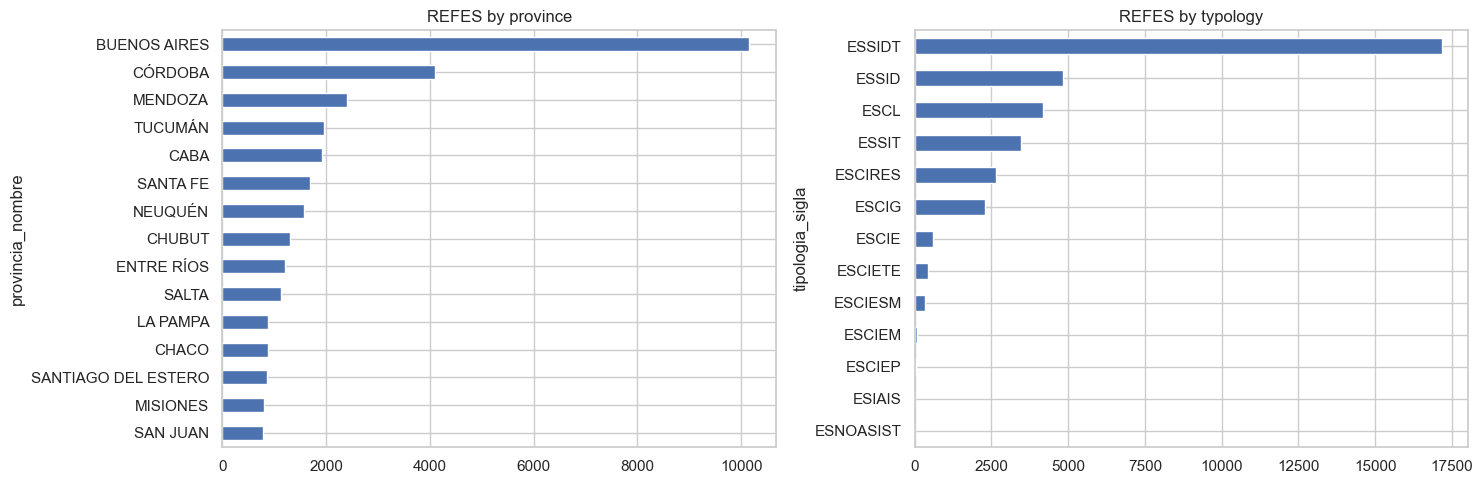

Valid-looking coordinates used in map: 28327 of 28352


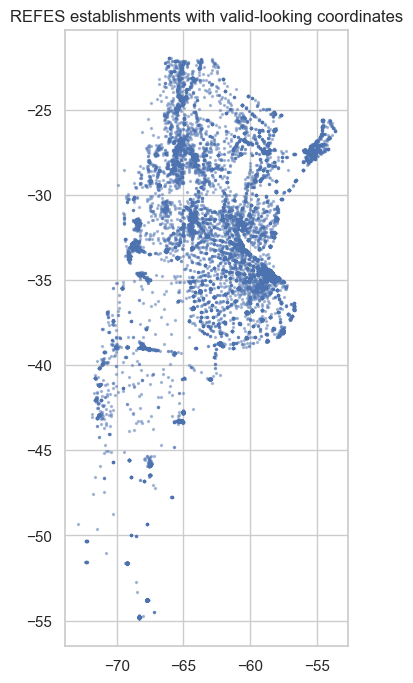

In [10]:
fig,axes=plt.subplots(1,2,figsize=(15,5)); refes["provincia_nombre"].value_counts().head(15).sort_values().plot.barh(ax=axes[0]); axes[0].set_title("REFES by province"); refes["tipologia_sigla"].value_counts().head(15).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("REFES by typology"); plt.tight_layout(); plt.show(); refes_points=refes.loc[refes["coordinate_status"] == "valid_argentina_bounds"].copy(); print("Valid-looking coordinates used in map:",len(refes_points),"of",refes[["longitud","latitud"]].dropna().shape[0]); refes_map=gpd.GeoDataFrame(refes_points,geometry=gpd.points_from_xy(refes_points["longitud"],refes_points["latitud"]),crs="EPSG:4326"); print("REFES map CRS:",refes_map.crs); refes_map.plot(figsize=(8,8),markersize=2,alpha=.4); plt.title("REFES establishments after coordinate validation"); plt.show()

## 4. BAHRA GeoJSON

In [11]:
bahra_all=gpd.read_file(ROOT / "base_total.geojson" / "base_total.geojson"); bahra_all_crs=bahra_all.to_crs("EPSG:4326") if bahra_all.crs is None else bahra_all.to_crs("EPSG:4326"); bahra_centroid_lat=bahra_all_crs.geometry.centroid.y; bahra=bahra_all_crs.loc[bahra_centroid_lat >= -60].copy(); print("BAHRA before Antarctica cut:",len(bahra_all_crs)); print("BAHRA removed south of 60°S:",len(bahra_all_crs)-len(bahra)); print("Shape after cut:",bahra.shape,"CRS:",bahra.crs); display(bahra.head()); display(bahra.dtypes.to_frame("dtype")); bahra_missing=bahra.drop(columns="geometry").isna().sum().to_frame("missing"); bahra_missing["missing_pct"]=bahra_missing["missing"]/len(bahra)*100; display(bahra_missing.sort_values("missing",ascending=False)); print("Empty geometries:",bahra.geometry.is_empty.sum(),"Invalid geometries:",(~bahra.geometry.is_valid).sum()); display(bahra["tipo"].value_counts(dropna=False).to_frame("settlements")); display(bahra.groupby(["nom_pcia","tipo"],dropna=False).size().unstack(fill_value=0).head(15))

Shape: (14673, 18) CRS: EPSG:4326


,id,cod_pcia,nom_pcia,cod_depto,nom_depto,cod_ase,nombre,tipo,cod_aglo,nom_aglo,cod_agl,nom_agl,lat_gd,long_gd,lat_gs,long_gs,fuente,geometry
0,780.0,06,Buenos Aires,06021,Alberti,06021A06,Palantelén,Paraje,NaN,NaN,060021,Alberti,-35.167391,-60.334732,"-35º10' 3""","-60º20' 5""",INDEC. ACA,MULTIPOINT (-60.33473 -35.16739)
1,851.0,06,Buenos Aires,06049,Azul,06049A30,Vicente Pereda,Paraje,NaN,NaN,060049,Azul,-36.698608,-59.782276,"-36º41'55""","-59º46'56""",INDEC. ACA,MULTIPOINT (-59.78228 -36.69861)
2,446.0,14,Córdoba,14014,Capital,1401401002,La Floresta,Entidad,0002,Gran Córdoba,140077,Córdoba,-31.396847,-64.059869,"-31º23'49""","-64º 3'36""",INDEC,MULTIPOINT (-64.05987 -31.39685)
3,572.0,50,Mendoza,50028,Guaymallén,5002802001,Bermejo,Entidad,0004,Gran Mendoza,500028,Guaymallén,-32.867313,-68.779540,"-32º52' 2""","-68º46'46""",INDEC,MULTIPOINT (-68.77954 -32.86731)
4,1324.0,06,Buenos Aires,06231,Daireaux,06231A09,Luro,Paraje,NaN,NaN,060231,Daireaux,-36.650001,-62.117106,"-36º39' 0""","-62º 7' 2""",IGN. SIG 250,MULTIPOINT (-62.11711 -36.65)


,dtype
id,float64
cod_pcia,str
nom_pcia,str
cod_depto,str
nom_depto,str
cod_ase,str
nombre,str
tipo,str
cod_aglo,str
nom_aglo,str


,missing,missing_pct
nom_aglo,10444,71.178355
cod_aglo,10439,71.144279
long_gs,1,0.006815
nom_depto,1,0.006815
id,0,0.000000
cod_depto,0,0.000000
cod_ase,0,0.000000
nom_pcia,0,0.000000
cod_pcia,0,0.000000
tipo,0,0.000000


Empty geometries: 0 Invalid geometries: 0


,settlements
tipo,
Paraje,10425
Localidad simple,3255
Entidad,707
Componente de localidad compuesta,273
Base Antártica,13


tipo,Base Antártica,Componente de localidad compuesta,Entidad,Localidad simple,Paraje
nom_pcia,,,,,
Buenos Aires,0,53,350,540,1414
Catamarca,0,9,38,145,325
Chaco,0,6,0,85,704
Chubut,0,0,22,68,202
Ciudad de Buenos Aires,0,1,48,0,0
Corrientes,0,1,0,76,551
Córdoba,0,71,43,452,950
Entre Ríos,0,7,14,162,488
Formosa,0,0,2,62,359


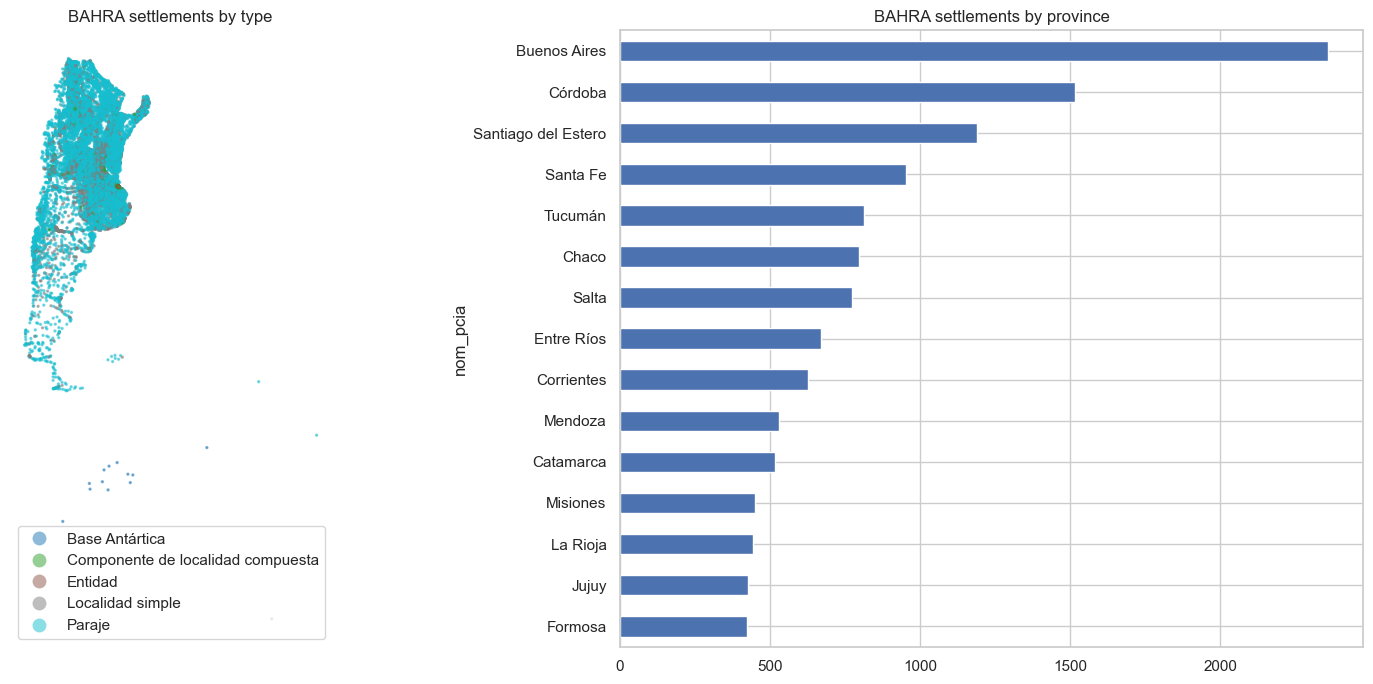

In [12]:
fig,axes=plt.subplots(1,2,figsize=(16,7)); bahra.plot(ax=axes[0],column="tipo",markersize=2,alpha=.5,legend=True); axes[0].set_title("BAHRA settlements by type"); axes[0].set_axis_off(); bahra["nom_pcia"].value_counts().head(15).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("BAHRA settlements by province"); plt.tight_layout(); plt.show()

## 5. Census radios Shapefile

In [13]:
radios_raw=gpd.read_file(ROOT / "radios_censales2" / "radios_censales2.shp",encoding="cp1252"); print("Shape:",radios_raw.shape); print("CRS read from .prj:",radios_raw.crs); print("CRS documented in metadatos_radios_censales.pdf: EPSG:4326"); print("Raw bounds:",radios_raw.total_bounds); radios_all=radios_raw.to_crs("EPSG:4326"); print("CRS after correction:",radios_all.crs); print("Corrected longitude/latitude bounds before Antarctica cut:",radios_all.total_bounds); radios_centroid_lat=radios_all.to_crs("EPSG:3857").centroid.to_crs("EPSG:4326").y; radios=radios_all.loc[radios_centroid_lat >= -60].copy(); print("Census radios before Antarctica cut:",len(radios_all)); print("Census radios removed south of 60°S:",len(radios_all)-len(radios)); print("Corrected longitude/latitude bounds after cut:",radios.total_bounds); display(radios.head()); display(radios.dtypes.to_frame("dtype")); radios_missing=radios.drop(columns="geometry").isna().sum().to_frame("missing"); radios_missing["missing_pct"]=radios_missing["missing"]/len(radios)*100; display(radios_missing.sort_values("missing",ascending=False)); print("Duplicate radio IDs:",radios["id"].duplicated().sum()); print("Empty geometries:",radios.geometry.is_empty.sum(),"Invalid geometries:",(~radios.geometry.is_valid).sum()); display(radios["tro"].value_counts(dropna=False).to_frame("radios")); display(radios.groupby(["jur","tro"],dropna=False).size().unstack(fill_value=0).head(15))

c:\Users\anapa\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: radios_censales2\radios_censales2.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


Shape: (66515, 12)
CRS reported by file: EPSG:3857
CRS documented in metadatos_radios_censales.pdf: EPSG:4326


,fid,id,cpr,jur,cde,dpto,cfn,cro,tro,cod_indec,sag,geometry
0,63497,87915.0,58,Neuquén,58035,Confluencia,11,12,U,580351112,INDEC,"POLYGON ((-7579132.531 -4718696.528, -7579045...."
1,63498,87914.0,58,Neuquén,58035,Confluencia,11,11,U,580351111,INDEC,"POLYGON ((-7577901.557 -4719060.088, -7577901...."
2,63499,73751.0,06,Buenos Aires,06035,Avellaneda,14,10,U,060351410,INDEC,"POLYGON ((-6495668.78 -4119506.721, -6495824.8..."
3,63500,87916.0,58,Neuquén,58035,Confluencia,11,13,U,580351113,INDEC,"POLYGON ((-7579140.773 -4720564.682, -7579171...."
4,63501,39772.0,22,Chaco,22140,San Fernando,12,06,U,221401206,INDEC,"POLYGON ((-6566928.644 -3180136.461, -6566832...."


,dtype
fid,int32
id,float64
cpr,str
jur,str
cde,str
dpto,str
cfn,str
cro,str
tro,str
cod_indec,str


,missing,missing_pct
tro,26,0.039089
id,0,0.000000
fid,0,0.000000
cpr,0,0.000000
jur,0,0.000000
dpto,0,0.000000
cde,0,0.000000
cfn,0,0.000000
cro,0,0.000000
cod_indec,0,0.000000


Duplicate radio IDs: 0
Empty geometries: 0 Invalid geometries: 3


,radios
tro,
U,54459
R,9347
M,2683
NaN,26


tro,M,R,U,NaN
jur,,,,
Buenos Aires,0,3230,20671,0
Catamarca,66,163,464,0
Chaco,70,470,1407,0
Chubut,32,138,858,0
Ciudad Autónoma de Buenos Aires,0,0,3820,0
Corrientes,139,674,1172,0
Córdoba,512,493,5715,0
Entre Ríos,176,1078,1959,11
Formosa,81,198,702,0


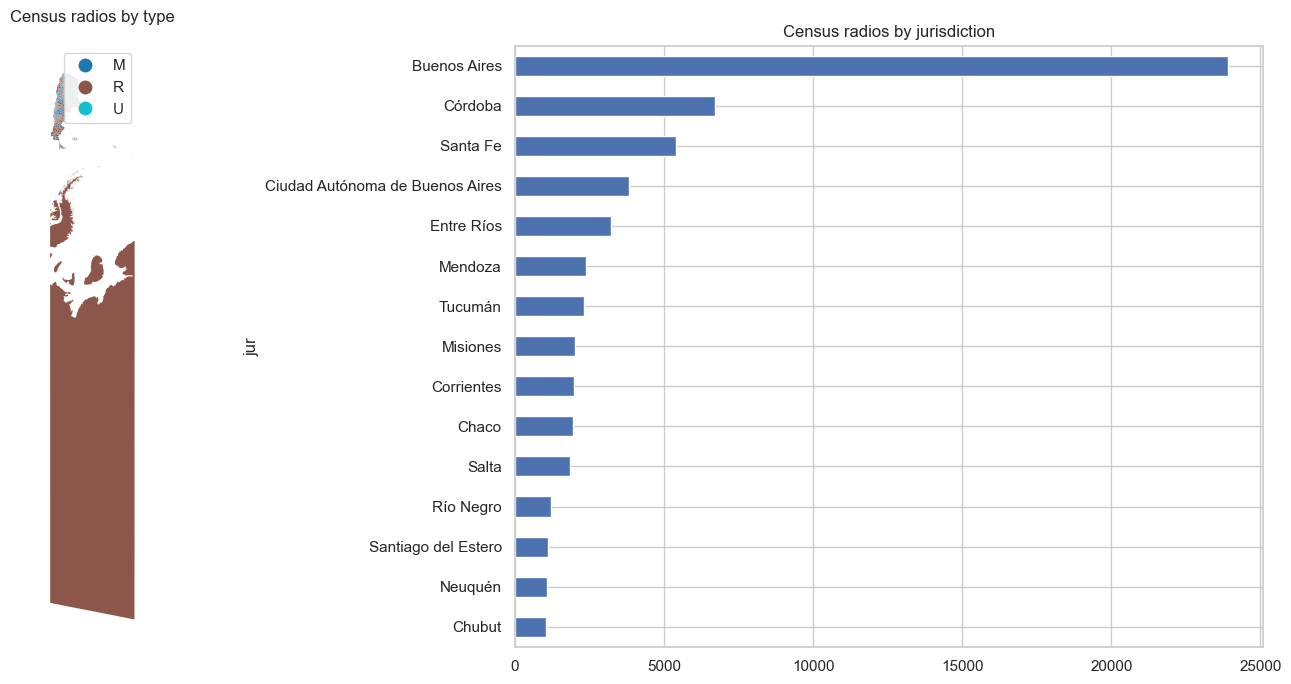

In [14]:
fig,axes=plt.subplots(1,2,figsize=(16,7)); radios.plot(ax=axes[0],column="tro",legend=True,linewidth=.05); axes[0].set_title("Census radios after reprojection to EPSG:4326"); axes[0].set_axis_off(); radios["jur"].value_counts().head(15).sort_values().plot.barh(ax=axes[1]); axes[1].set_title("Census radios by jurisdiction"); plt.tight_layout(); plt.show()

## Notes for continued work

The objects `enfermeria`, `medicos`, `refes`, `refes_map`, `bahra_all`, filtered `bahra`, `radios_raw`, `radios_all`, and filtered `radios` remain available. REFES rows are retained in `refes` with an auditable `coordinate_status`; only `valid_argentina_bounds` rows are used in `refes_map`. BAHRA and census radios are filtered to centroid latitude >= -60°S to exclude Antarctica before mapping or spatial joins. The census-radio layer is read in the CRS declared by its `.prj` (EPSG:3857) and reprojected to the documented analytical CRS EPSG:4326. Use `sum(total)` for professional counts.